# 11 · Ordinary differential equations: a batch reactor

**Problem.** In a batch reactor the desired product B is formed from A and then degrades to C:
$$A \xrightarrow{k_1} B \xrightarrow{k_2} C,\qquad
\frac{dC_A}{dt} = -k_1 C_A,\quad \frac{dC_B}{dt} = k_1 C_A - k_2 C_B,\quad \frac{dC_C}{dt} = k_2 C_B .$$
When should the reaction be stopped to maximise B? The exact solution exists here, so every
numerical method can be checked.

**What you will learn**

- solve systems of ODEs with Euler and Runge-Kutta methods
- implement a Runge-Kutta 4 step and verify its order against an exact solution
- use adaptive step-size control
- recognise stiffness and use an implicit method

**Before you start:** notebook 00 and 10 (golden-section search); first-order reaction kinetics  ·  **Time:** about 60-75 min

Run the cells in order (Shift + Enter). Then change the numbers and run them again - that is how the
ideas sink in.

In [1]:
try:                      # on Google Colab (or anywhere engmath is missing): install it from GitHub
    import engmath
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engmath"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import engmath
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")
from engmath import odes, optimize

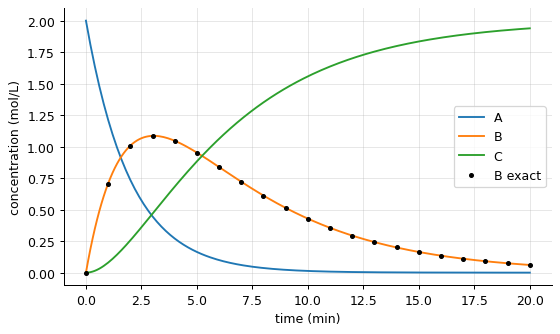

mass balance check: max |A+B+C - CA0| = 2.2e-15


In [2]:
k1, k2, CA0 = 0.5, 0.2, 2.0          # 1/min, 1/min, mol/L
def rhs(t, c):
    return [-k1*c[0], k1*c[0] - k2*c[1], k2*c[1]]

def CB_exact(t):
    return CA0*k1/(k2 - k1)*(np.exp(-k1*t) - np.exp(-k2*t))

t, c = odes.rk4(rhs, [CA0, 0, 0], 0, 20, 200)
for i, name in enumerate("ABC"):
    plt.plot(t, c[:, i], label=name)
plt.plot(t[::10], CB_exact(t[::10]), "k.", label="B exact")
plt.xlabel("time (min)"); plt.ylabel("concentration (mol/L)"); plt.legend(); plt.show()
print(f"mass balance check: max |A+B+C - CA0| = {np.max(np.abs(c.sum(axis=1) - CA0)):.1e}")

## Inside the algorithm: one Runge-Kutta 4 step
RK4 samples the slope four times per step - at the start, twice at the midpoint and at the end - and
averages them with weights 1, 2, 2, 1:

In [3]:
def rk4_step(f, t, y, h):
    k1 = np.array(f(t, y))
    k2 = np.array(f(t + h/2, y + h/2 * k1))
    k3 = np.array(f(t + h/2, y + h/2 * k2))
    k4 = np.array(f(t + h, y + h * k3))
    return y + h/6 * (k1 + 2*k2 + 2*k3 + k4)

y, h = np.array([CA0, 0.0, 0.0]), 0.1
for step in range(200):
    y = rk4_step(rhs, step * h, y, h)
print("by hand:", y)
print("library:", c[-1])

by hand: [9.07999088e-05 6.09007968e-02 1.93900840e+00]
library: [9.07999088e-05 6.09007968e-02 1.93900840e+00]


## Optimal batch time: maximise $C_B(t)$

In [4]:
def neg_CB(t_end):
    n = max(10, int(t_end*20))
    return -odes.rk4(rhs, [CA0, 0, 0], 0, t_end, n)[1][-1, 1]

best = optimize.golden_section(neg_CB, 0.5, 10)
t_opt_exact = np.log(k1/k2)/(k1 - k2)
print(f"optimal time {best.x[0]:.4f} min (exact ln(k1/k2)/(k1-k2) = {t_opt_exact:.4f}), max C_B = {-best.fun:.4f} mol/L")

optimal time 3.0543 min (exact ln(k1/k2)/(k1-k2) = 3.0543), max C_B = 1.0858 mol/L


## Accuracy: Euler vs RK4
The global error of Euler's method is proportional to the step $h$; RK4's to $h^4$. Halving the step
halves Euler's error but reduces RK4's 16-fold.

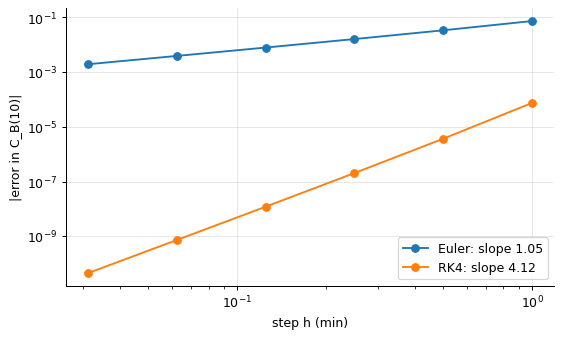

In [5]:
ns = np.array([10, 20, 40, 80, 160, 320])
fig, ax = plt.subplots()
for name, solver in (("Euler", odes.euler), ("RK4", odes.rk4)):
    err = [abs(solver(rhs, [CA0, 0, 0], 0, 10, n)[1][-1, 1] - CB_exact(10)) for n in ns]
    slope = np.polyfit(np.log(10/ns), np.log(err), 1)[0]
    ax.loglog(10/ns, err, "o-", label=f"{name}: slope {slope:.2f}")
ax.set(xlabel="step h (min)", ylabel="|error in C_B(10)|"); ax.legend(); plt.show()

## Adaptive step size
`odes.rk23` estimates its own error at each step and adjusts $h$: small steps where the solution
changes fast, large where it is smooth.

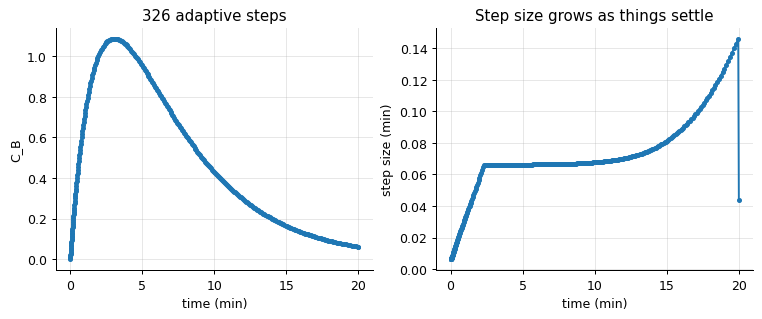

error at t = 20 min: 4.2e-08


In [6]:
ta, ca = odes.rk23(rhs, [CA0, 0, 0], 0, 20, rtol=1e-6)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.5))
a1.plot(ta, ca[:, 1], "o-", ms=3); a1.set(xlabel="time (min)", ylabel="C_B", title=f"{ta.size - 1} adaptive steps")
a2.plot(ta[1:], np.diff(ta), "o-", ms=3); a2.set(xlabel="time (min)", ylabel="step size (min)", title="Step size grows as things settle")
plt.show()
print(f"error at t = 20 min: {abs(ca[-1, 1] - CB_exact(20)):.1e}")

## Stiffness: when explicit methods fail
If B is an unstable intermediate ($k_2$ = 1000 1/min), the fast time scale forces explicit methods
to take tiny steps **for stability, not accuracy** - even after B has reached its quasi-steady level.
Implicit methods such as backward Euler remain stable with large steps.

In [7]:
k2_fast = 1000.0
stiff = lambda t, c: [-k1*c[0], k1*c[0] - k2_fast*c[1]]
exact_B = lambda t: CA0*k1/(k2_fast - k1)*(np.exp(-k1*t) - np.exp(-k2_fast*t))
for n in (100, 1000, 10000):
    h = 10/n
    tb, cb = odes.backward_euler(stiff, [CA0, 0], 0, 10, n)
    with np.errstate(over="ignore", invalid="ignore"):     # the explicit run is EXPECTED to overflow
        te, ce = odes.euler(stiff, [CA0, 0], 0, 10, n)
    print(f"h = {h:7.4f} min (k2 h = {k2_fast*h:6.1f}):  explicit Euler C_B(10) = {ce[-1, 1]:11.3e}   "
          f"backward Euler = {cb[-1, 1]:.4e}   exact = {exact_B(10):.4e}")

h =  0.1000 min (k2 h =  100.0):  explicit Euler C_B(10) = -3.662e+196   backward Euler = 7.6083e-06   exact = 6.7413e-06
h =  0.0100 min (k2 h =   10.0):  explicit Euler C_B(10) =         nan   backward Euler = 6.8258e-06   exact = 6.7413e-06


h =  0.0010 min (k2 h =    1.0):  explicit Euler C_B(10) =   6.733e-06   backward Euler = 6.7497e-06   exact = 6.7413e-06


Explicit Euler is stable only for $k_2 h < 2$. In practice use SciPy's `solve_ivp(method="BDF")` or
`"Radau"` for stiff systems - the ideas are exactly those shown here.

## Exercises
1. A tank drains through an orifice: $A\,dh/dt = -C_d a\sqrt{2gh}$. Solve with RK4 and compare with
   the exact draining time $t = (A/C_d a)\sqrt{2h_0/g}$. Why does the error grow near $h = 0$?
2. For the series reaction, find the $k_1$ that maximises $C_B$ at a fixed batch time of 3 min
   (an optimisation wrapped around an ODE solver).
3. Estimate the largest stable step for RK4 on the stiff system by trial. Compare with the Euler
   limit $h < 2/k_2$.
4. **Implement it yourself:** Heun's method predicts with an Euler step and corrects with the average of the start and end slopes. Implement it, measure its order on the series reaction, and place it between Euler and RK4.